In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm


from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.utils import shuffle

from imblearn.over_sampling import SMOTE  # Pour l'équilibrage des classes

In [3]:
# Définir les noms des classes
classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
label_map = {label: idx + 1 for idx, label in enumerate(classes)}

# Définir le chemin vers le dossier DATASET 
dataset_path = r"C:\Users\Pc\Downloads\ML.CNN\DATASET"


In [4]:
def load_data(dataset_dir, label_map):
    images = []
    labels = []
    for label, idx in tqdm(label_map.items(), desc="Chargement des images"):
        folder_path = os.path.join(dataset_dir, str(idx))
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_rgb = cv2.resize(img_rgb, (48, 48))
                images.append(img_rgb)
                labels.append(idx)
    return np.array(images), np.array(labels)


In [5]:
# Charger les images
images, labels = load_data(dataset_path, label_map)
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

# Aplatir et normaliser
X_flat = images.reshape(images.shape[0], -1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# Séparation train/test
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, labels, test_size=0.25, random_state=42, shuffle=True
)


Chargement des images: 100%|██████████| 7/7 [00:06<00:00,  1.08it/s]


Images shape: (20133, 48, 48, 3), Labels shape: (20133,)


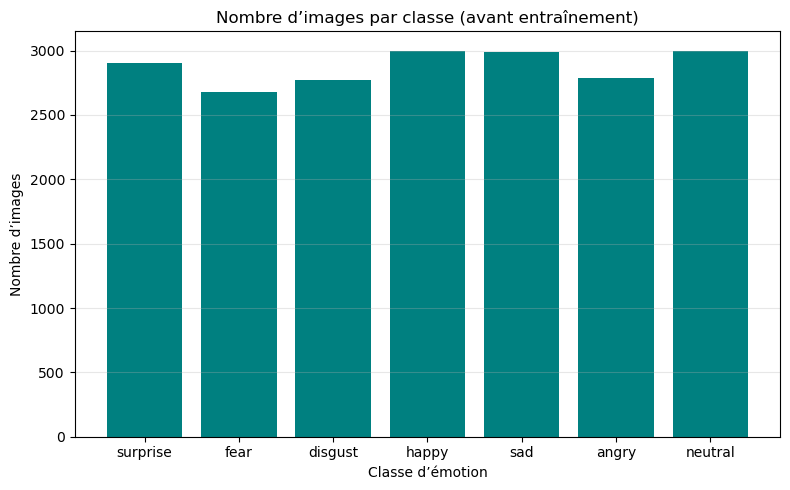

surprise: 2904 images
fear: 2680 images
disgust: 2775 images
happy: 3000 images
sad: 2988 images
angry: 2786 images
neutral: 3000 images


In [6]:
# Compter les images par classe
label_counts = {}
for class_id in sorted(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, class_id)
    if os.path.isdir(class_dir):
        count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        label_counts[int(class_id)] = count

# Trier et afficher
label_counts = dict(sorted(label_counts.items()))
counts = [label_counts.get(i + 1, 0) for i in range(7)]  # i+1 car les classes vont de 1 à 7

# Graphique de répartition
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='teal')
plt.title("Nombre d’images par classe (avant entraînement)")
plt.xlabel("Classe d’émotion")
plt.ylabel("Nombre d’images")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Affichage texte
for name, count in zip(classes, counts):
    print(f"{name}: {count} images")


In [7]:
kernels = ['linear', 'rbf', 'poly']
models = {}
accuracies = {}


for kernel in kernels:
    print(f" Entraînement SVM kernel='{kernel}'") 
    model = SVC(kernel=kernel)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    models[kernel] = model
    accuracies[kernel] = accuracy
    print(f" Accuracy {kernel}: {accuracy * 100:.2f}%")

 Entraînement SVM kernel='linear'
 Accuracy linear: 60.31%
 Entraînement SVM kernel='rbf'
 Accuracy rbf: 75.78%
 Entraînement SVM kernel='poly'
 Accuracy poly: 71.71%


In [8]:
# Évaluation du meilleur modèle
best_kernel = max(accuracies, key=accuracies.get)
best_model = models[best_kernel]
y_pred = best_model.predict(X_test)

print("\n📊 Rapport de classification :")
print(classification_report(Y_test, y_pred, target_names=classes))



📊 Rapport de classification :
              precision    recall  f1-score   support

    surprise       0.84      0.74      0.79       717
        fear       0.99      0.91      0.95       667
     disgust       0.94      0.71      0.81       706
       happy       0.73      0.79      0.76       762
         sad       0.62      0.58      0.60       735
       angry       0.92      0.83      0.87       713
     neutral       0.50      0.76      0.61       734

    accuracy                           0.76      5034
   macro avg       0.79      0.76      0.77      5034
weighted avg       0.79      0.76      0.77      5034



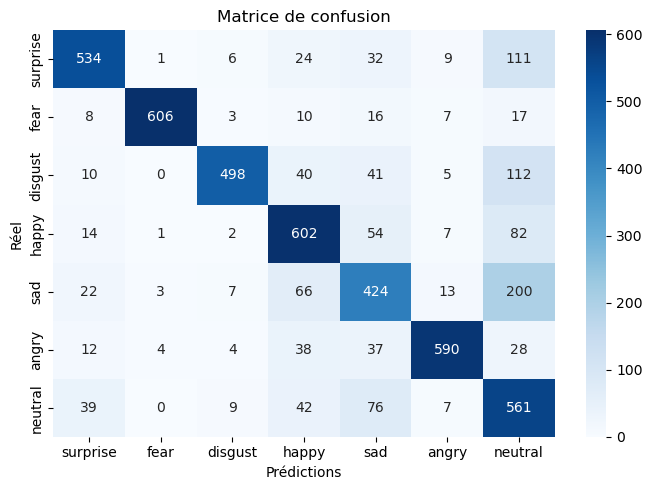

In [9]:
#  Matrice de confusion
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()


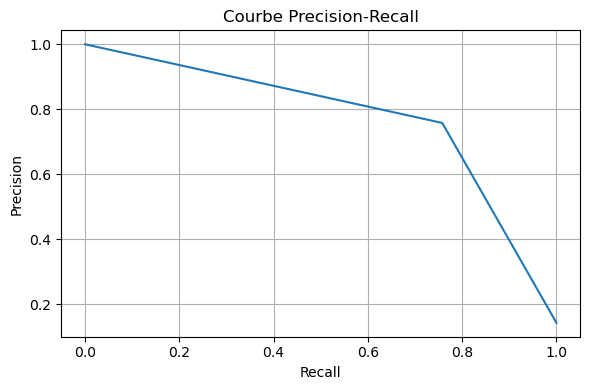

In [10]:
from sklearn.preprocessing import label_binarize  # à importer en haut

# Binarisation des labels
y_test_bin = label_binarize(Y_test, classes=range(1, 8))
y_pred_bin = label_binarize(y_pred, classes=range(1, 8))

# Courbe Precision-Recall
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_pred_bin.ravel())

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label="Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.grid(True)
plt.tight_layout()
plt.show()


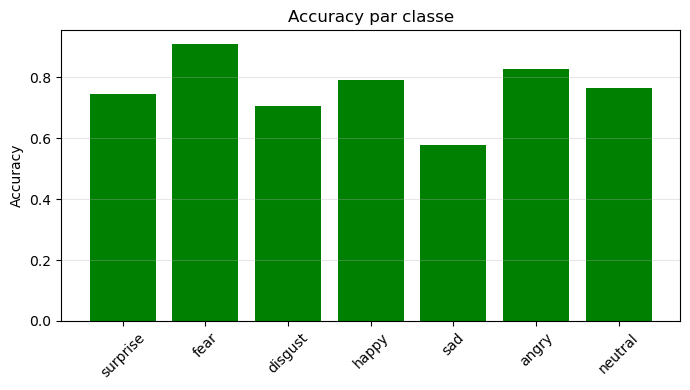

In [11]:
#  Accuracy par classe
class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(7, 4))
plt.bar(classes, class_accuracy, color='green')
plt.title('Accuracy par classe')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

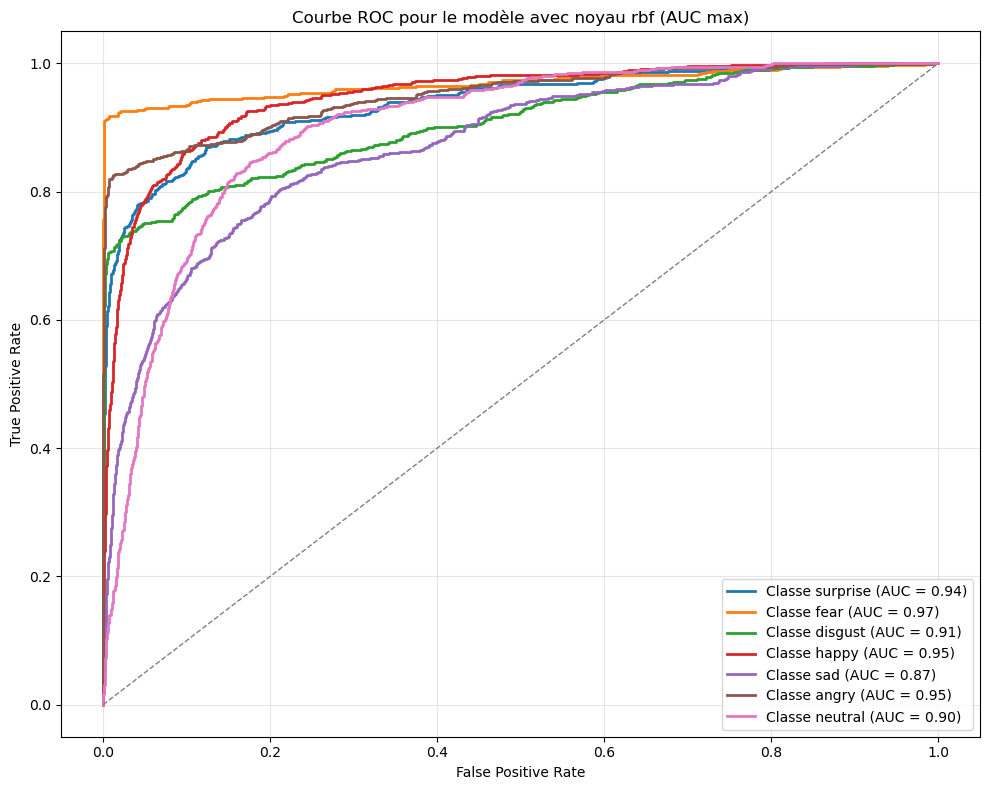

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
# Binariser les labels pour le calcul des courbes ROC multi-classe
y_test_bin = label_binarize(Y_test, classes=range(1, len(classes) + 1))  # Binarisation des labels
y_scores = best_model.decision_function(X_test)  # Scores de décision pour chaque classe

# Initialisation des FPR, TPR, et AUC pour chaque classe
fpr = {}
tpr = {}
roc_auc = {}
# Calcul des courbes ROC et de l'AUC pour chaque classe
plt.figure(figsize=(10, 8))
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Classe {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Ligne de référence pour une prédiction aléatoire
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Courbe ROC pour le modèle avec noyau {best_kernel} (AUC max)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 2. Afficher la forme du tableau
print("Shape des scores de décision :", y_scores.shape)

# 3. Afficher le nombre de classes uniques dans Y_test
print("Nombre de classes dans Y_test :", len(classes))

Shape des scores de décision : (5034, 7)
Nombre de classes dans Y_test : 7


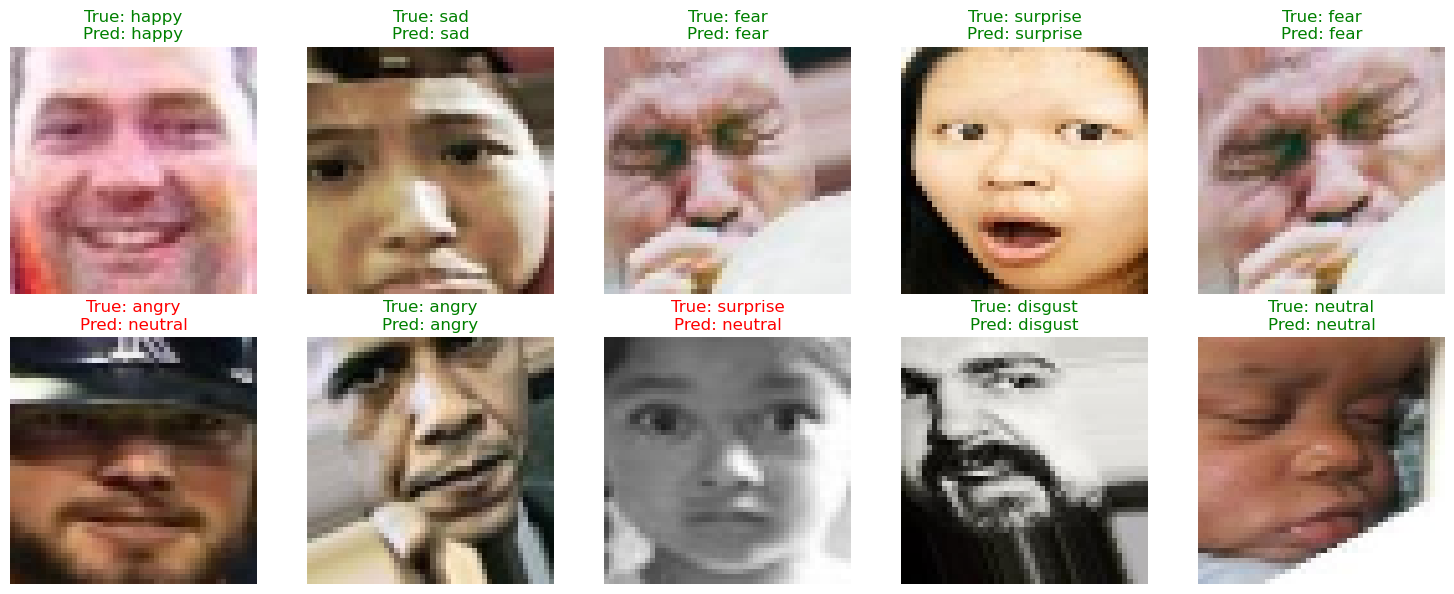

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Refaire le même split pour récupérer les images du test
_, X_test_img, _, Y_test_labels = train_test_split(
    images, labels, test_size=0.25, random_state=42, shuffle=True
)

# 🔹 Prédictions du modèle SVM
y_pred_svm = best_model.predict(X_test)

# 🔹 Sélection de 10 indices aléatoires
random_indices = np.random.choice(len(X_test_img), 10, replace=False)

# 🔹 Affichage
fig, ax = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(random_indices):
    image = X_test_img[idx]  # 48x48 image (grayscale)
    true_class = classes[Y_test_labels[idx] - 1]
    pred_class = classes[y_pred_svm[idx] - 1]

    ax[i // 5, i % 5].imshow(image, cmap='gray')
    ax[i // 5, i % 5].axis('off')

    # Titre coloré selon la justesse de la prédiction
    color = 'green' if true_class == pred_class else 'red'
    ax[i // 5, i % 5].set_title(f'True: {true_class}\nPred: {pred_class}', color=color)
plt.tight_layout()
plt.show()


In [23]:
import joblib

joblib.dump(best_model, f'svm_model_{best_kernel}_emotion.pkl')
print(f" Modèle SVM ({best_kernel}) sauvegardé dans 'svm_model_{best_kernel}_emotion.pkl'")

 Modèle SVM (rbf) sauvegardé dans 'svm_model_rbf_emotion.pkl'


In [24]:
joblib.dump(scaler, "scaler_svm_emotion.pkl")
print("Scaler enregistré dans 'scaler_svm_emotion.pkl'")

Scaler enregistré dans 'scaler_svm_emotion.pkl'
